In [ ]:
import ast

s = '''
match x:
    case Point.Var(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

Visiting  __new__
CallReturnWires(regular_returns=[OutPort(Node(13), 0)], inout_returns=[])
OutPort(Node(13), 0) Tuple(int<6>, int<6>)
...
OutPort(Node(13), 0) Tuple(int<6>, int<6>)
---
Visiting  __and__
Visiting  __eq__
CallReturnWires(regular_returns=[OutPort(Node(15), 0)], inout_returns=[])
OutPort(Node(15), 0) bool
...
Visiting  __gt__
CallReturnWires(regular_returns=[Node(19)], inout_returns=[])
Node(19) bool
...
CallReturnWires(regular_returns=[OutPort(Node(20), 0)], inout_returns=[])
OutPort(Node(20), 0) bool
...
Visiting  __eq__
CallReturnWires(regular_returns=[Node(39)], inout_returns=[])
Node(39) bool
...
Node(39) bool
---


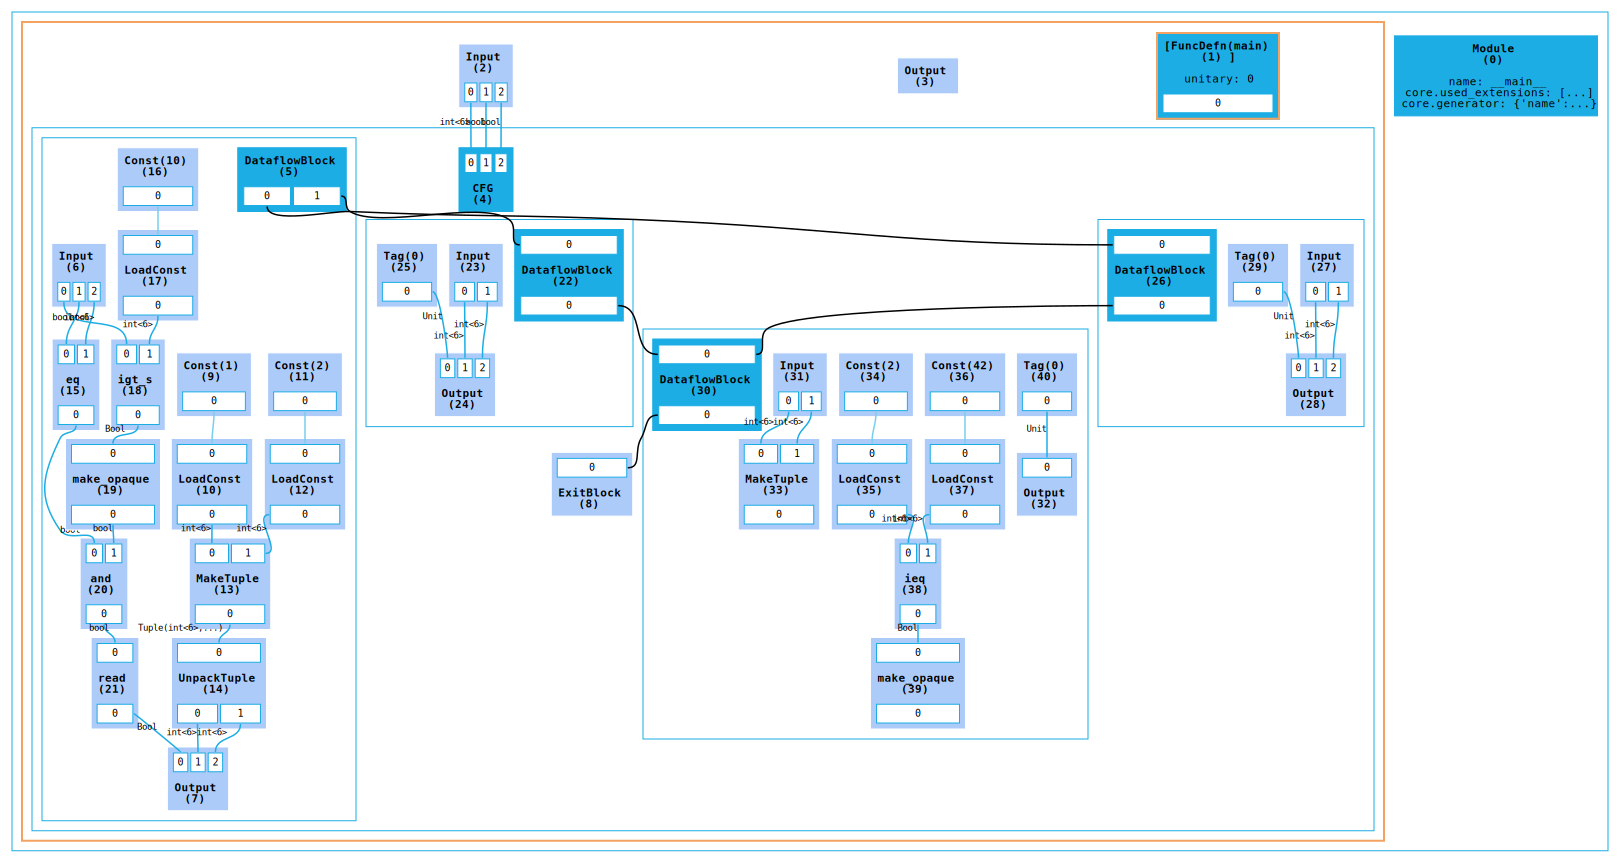

In [4]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(a: int, b: bool, c : bool) -> None:
    s = Point(1, 2)
    
    if (b == c) & (a > 10):
        pass
    
    s
    d = 2 == 42
main.compile_function().modules[0].render_dot(RenderConfig(display_node_id=True))

In [1]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(a: int, b: bool, c : bool) -> None:
    s = Point(1, 2)
    match s:
        case _:
            pass
    
    d = 2 == 42
main.compile_function().modules[0].render_dot()

Tuple(int<6>, int<6>)
<class 'hugr.hugr.node_port.OutPort'>


Traceback (most recent call last):
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/sx/bbzfd6mn5txdvh5bghnjgp5m0000gp/T/ipykernel_78253/4272690214.py", line 22, in <module>
    main.compile_function().modules[0].render_dot()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 205, in compile_function
    return super().compile()
           ~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 77, in compile
    package: Package = ENGINE.compile(self.id).package
                       ~~~~~~~~~~~~~~^^^^^^^^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang-internals/src/guppylang_internals/error.py", line 122,

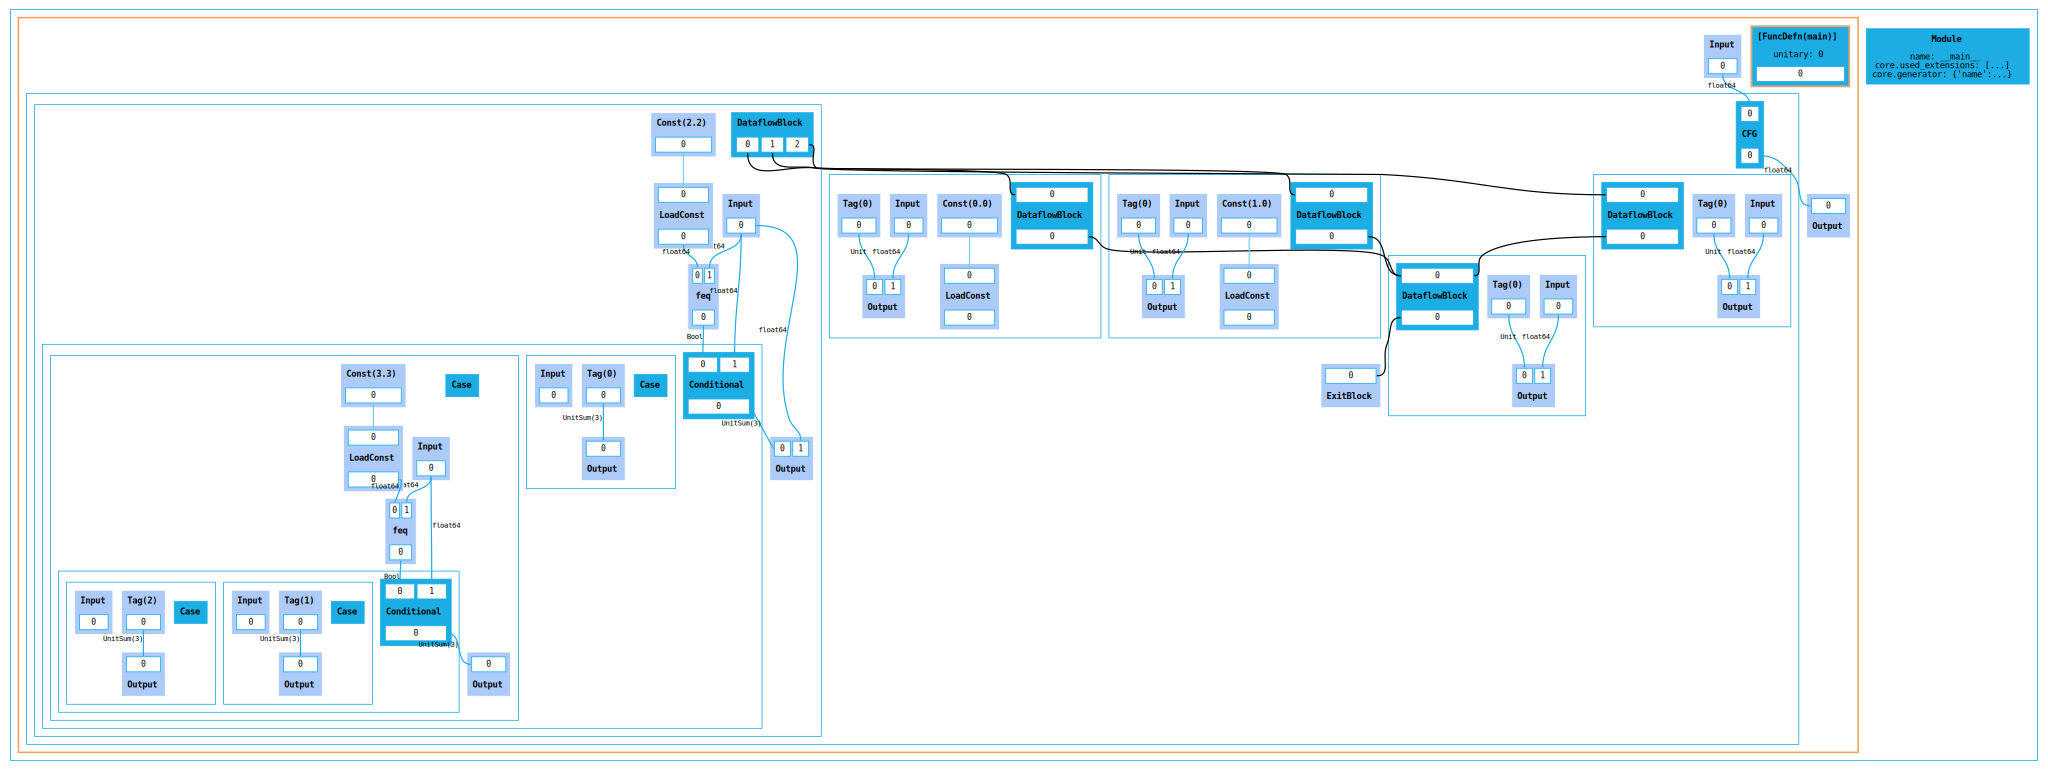

In [1]:

from guppylang import guppy

@guppy
def main(x:float) -> float:
    match x:
        case 2.2:
            r = 0.0
        case 3.3:
            r = 1.0
        case _:
            pass

    return x


main.compile_function().modules[0].render_dot()

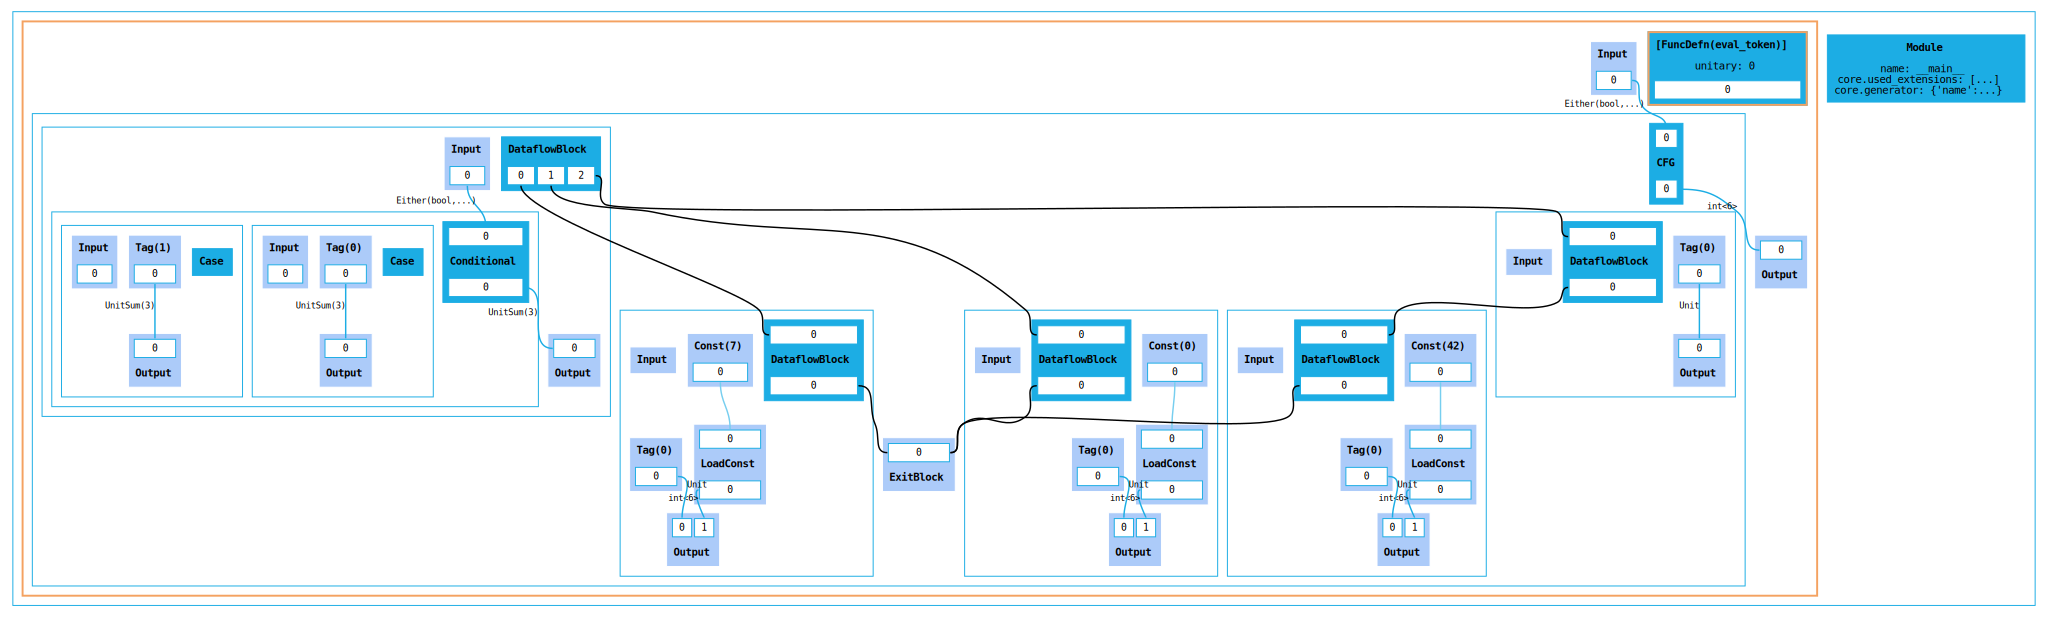

In [5]:
from guppylang import guppy
from selene_hugr_qis_compiler import check_hugr


@guppy.enum
class Token:
    # else_cond = {}
    bool_lit = {"b": bool}
    int_lit = {"n": int}
    # second_cond = {}

@guppy
def eval_token(t: Token) -> int:
    match t:
        case Token.int_lit(_):
            return 7
        case Token.bool_lit(_):
            return 0
        case _:
            pass

    
    return 42

h = eval_token.compile_function().modules[0]
check_hugr(h.to_bytes())
h.render_dot()


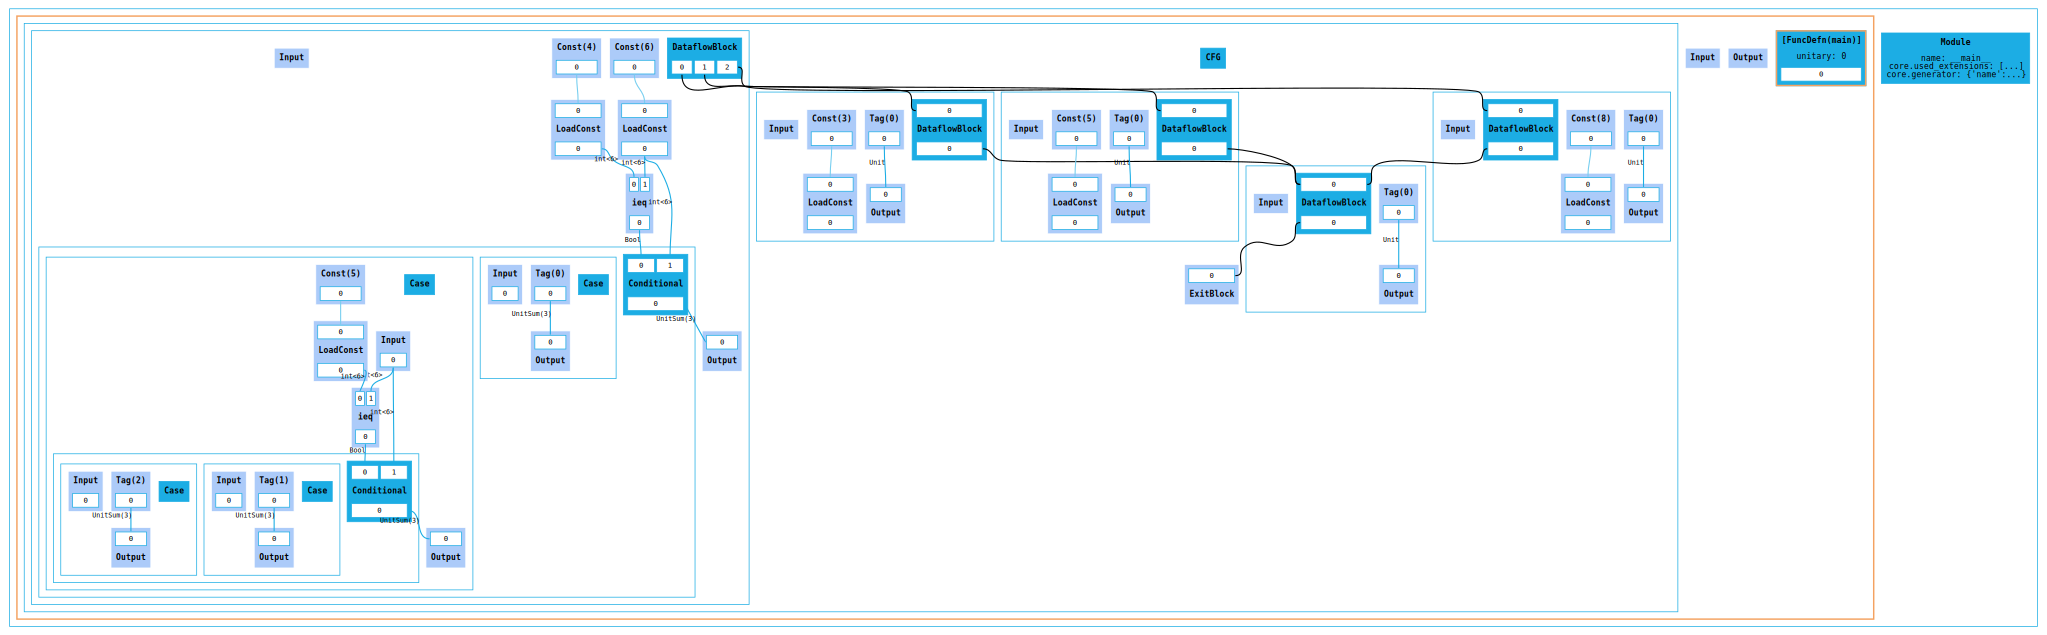

In [6]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h
from selene_hugr_qis_compiler import check_hugr



@guppy
def main() -> None:
    match 6:
        case 4:
            x = 3
        case 5:
            x = 5
        case _:
            x = 8
    


h = main.compile_function()
check_hugr(h.to_bytes())

h.modules[0].render_dot()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [24]:
# Example: linear variable used in multiple match arms (should error if not allowed)

from guppylang import guppy
from guppylang.std.quantum import qubit, measure
from guppylang.std.array import array
import guppylang

guppylang.enable_experimental_features()

@guppy.enum
class Point:
    x = {"n": str}
    y = {"n": int}
    z ={"q": qubit}

@guppy
def fun() -> Point:
    return Point.x(qubit())

T = guppy.type_var("T")
@guppy
def met(self: Point) -> int:
    match []:
        case Point.z((qubit())):
            h(qubit)
            return 42
        case _:
            return 2


@guppy
def main(p: Point) -> None:
    e = Point.y(1)
    e.met()

    # describe_point(fun())

met.check()


Error: Cannot infer type (at <In[24]>:23:10)
   | 
21 | @guppy
22 | def met(self: Point) -> int:
23 |     match []:
   |           ^^ Cannot infer type variables in expression of type `list[?T]`

Guppy compilation failed due to 1 previous error


In [ ]:
from guppylang import guppy

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def main(p: Point) -> None:
    match p:
        case Point(_, _):
            b = 1
    a = b

main.check()

In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.enum
class Point:
    x = {"n": int}
    y = {"n": int}
    z = {"n": int}

    @guppy
    def enum(self: Point) -> None:
        pass

@guppy.struct
class Line:
    start: int
    end: int

    @guppy
    def struct(self: Line) -> None:
        pass

@guppy
def main() -> None:
    p = Point.x(1)
    p.enum()
    l = Line(2, 3)
    l.struct()

main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100)).view()
    

In [4]:
from collections import defaultdict


d = defaultdict(lambda: 42)
d[0] = 3
d[1]

42